In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [34]:
df = pd.read_excel(
    "final_hwahae_oliveyoung_6category.xlsx"
)

print(df.shape)

df.head()

(600, 13)


,category,hwahae_rank,product_name,hwahae_rating,hwahae_review,olive_search_query,olive_found,olive_brand,olive_product_name,olive_full_name,original_price,sale_price,discount_rate
0,skin_toner,1,에스네이처아쿠아 오아시스 토너,4.74,27245,에스네이처아쿠아 오아시스 토너,1,에스네이처,[속촉촉 진정토너] 에스네이처 아쿠아 오아시스 토너 300ml 기획 (+젤크림 30ml),에스네이처[속촉촉 진정토너] 에스네이처 아쿠아 오아시스 토너 300ml 기획 (+젤...,25000.0,18900.0,24.4
1,skin_toner,2,토리든다이브인 저분자 히알루론산 토너,4.70,34786,토리든다이브인 저분자 히알루론산 토너,1,토리든,[NEW/6월올영픽] 토리든 다이브인 저분자 히알루론산 토너 500ml 기획 (+늘...,토리든[NEW/6월올영픽] 토리든 다이브인 저분자 히알루론산 토너 500ml 기획 ...,29000.0,19000.0,34.5
2,skin_toner,3,토니모리세라마이드 모찌 토너,4.69,17493,토니모리세라마이드 모찌 토너,0,NaN,NaN,NaN,NaN,NaN,NaN
3,skin_toner,4,라운드랩1025 독도 토너,4.43,94669,라운드랩1025 독도 토너,1,라운드랩,[6월올영픽/미스트형] 라운드랩 1025 독도 토너 300ml 1+1 기획 (+늘어...,라운드랩[6월올영픽/미스트형] 라운드랩 1025 독도 토너 300ml 1+1 기획 ...,29800.0,25300.0,15.1
4,skin_toner,5,이즈앤트리초저분자 히아루론산 토너,4.70,9436,이즈앤트리초저분자 히아루론산 토너,1,이즈앤트리,이즈앤트리 초저분자 히아루론산 토너 300ml 리필기획 (+200ml 리필 + 미스...,이즈앤트리이즈앤트리 초저분자 히아루론산 토너 300ml 리필기획 (+200ml 리필...,33500.0,22500.0,32.8


데이터 확인

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   category            600 non-null    object 
 1   hwahae_rank         600 non-null    int64  
 2   product_name        600 non-null    object 
 3   hwahae_rating       600 non-null    float64
 4   hwahae_review       600 non-null    int64  
 5   olive_search_query  600 non-null    object 
 6   olive_found         600 non-null    int64  
 7   olive_brand         317 non-null    object 
 8   olive_product_name  317 non-null    object 
 9   olive_full_name     317 non-null    object 
 10  original_price      317 non-null    float64
 11  sale_price          317 non-null    float64
 12  discount_rate       317 non-null    float64
dtypes: float64(4), int64(3), object(6)
memory usage: 61.1+ KB


In [42]:
df.isnull().sum()

category                0
hwahae_rank             0
product_name            0
hwahae_rating           0
hwahae_review           0
olive_search_query      0
olive_found             0
olive_brand           283
olive_product_name    283
olive_full_name       283
original_price        283
sale_price            283
discount_rate         283
dtype: int64

입점 현황 확인

In [39]:
df["olive_found"].value_counts()

olive_found
1    317
0    283
Name: count, dtype: int64

In [40]:
df["olive_found"].value_counts(normalize=True)*100

olive_found
1    52.833333
0    47.166667
Name: proportion, dtype: float64

카테고리 확인

In [43]:
df["category"].value_counts()

category
skin_toner         100
lotion_emulsion    100
serum_ampoule      100
cream              100
mist               100
skin_pad           100
Name: count, dtype: int64

## 가설 1: 제품 카테고리에 따라 올리브영 입점률에 차이가 있을 것이다.

제품 카테고리와 올리브영 입점 여부 사이의 관계를 확인하기 위해 카이제곱 검정을 수행한다.

In [45]:
# 카테고리별 입점률
category_rate = (
    df.groupby("category")
      ["olive_found"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

category_rate

category
cream              70.0
serum_ampoule      66.0
skin_toner         57.0
skin_pad           50.0
lotion_emulsion    42.0
mist               32.0
Name: olive_found, dtype: float64

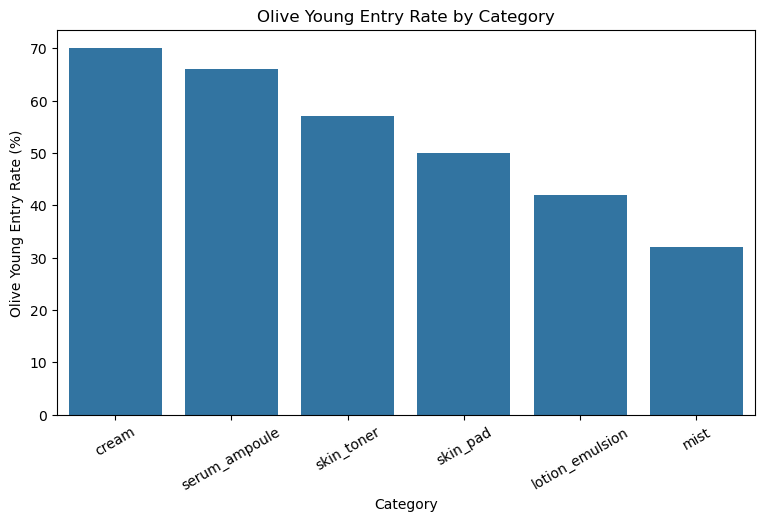

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,5))

sns.barplot(
    x=category_rate.index,
    y=category_rate.values
)

plt.ylabel("Olive Young Entry Rate (%)")
plt.xlabel("Category")
plt.title("Olive Young Entry Rate by Category")

plt.xticks(rotation=30)

plt.show()

In [47]:
table = pd.crosstab(
    df["category"],
    df["olive_found"]
)

table

olive_found,0,1
category,,
cream,30,70
lotion_emulsion,58,42
mist,68,32
serum_ampoule,34,66
skin_pad,50,50
skin_toner,43,57


카이제곱 검정

In [48]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 41.927968699490584
p-value: 6.091446924958995e-08


## 가설 2: 화해 제품의 소비자 반응(리뷰 수, 평점)은 올리브영 입점 여부를 설명할 수 있다.

화해 제품의 특성이 올리브영 입점 여부를 설명할 수 있는지 확인하기 위해 Random Forest 분류 모델을 구축한다.

In [133]:
model_df = df.copy()

# 리뷰 로그
model_df["log_review"] = np.log1p(
    model_df["hwahae_review"]
)

# 리뷰 × 평점
model_df["review_rating_score"] = (
    model_df["log_review"]
    * model_df["hwahae_rating"]
)

# 순위 그룹
model_df["rank_group"] = pd.cut(
    model_df["hwahae_rank"],
    bins=[0,20,50,100],
    labels=["Top20","Top50","Top100"]
)

In [ ]:
model_df[
    [
        "hwahae_rank",
        "rank_group",
        "review_rating_score"
    ]
].head()

,hwahae_rank,rank_group,review_rating_score
0,1,Top20,48.408018
1,2,Top20,49.147895
2,3,Top20,45.819486
3,4,Top20,50.759615
4,5,Top20,43.016249


In [136]:
X = model_df[
    [
        "hwahae_rating",
        "log_review",
        "review_rating_score",
        "category",
        "rank_group"
    ]
]

y = model_df["olive_found"]

In [137]:
X_encoded = pd.get_dummies(
    X,
    columns=[
        "category",
        "rank_group"
    ],
    drop_first=True
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf2 = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    max_depth=5

)

rf2.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', max_depth=5, n_estimators=500,
                       random_state=42)

In [140]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

y_pred = rf2.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred
    )
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.625
              precision    recall  f1-score   support

           0       0.64      0.49      0.55        57
           1       0.62      0.75      0.68        63

    accuracy                           0.62       120
   macro avg       0.63      0.62      0.62       120
weighted avg       0.63      0.62      0.62       120



In [ ]:
importance_df2 = pd.DataFrame({
    "feature": X_encoded.columns,
    "importance": rf2.feature_importances_
})

importance_df2 = (
    importance_df2
    .sort_values(
        "importance",
        ascending=False
    )
)

importance_df2

,feature,importance
2,review_rating_score,0.323237
1,log_review,0.284965
0,hwahae_rating,0.181306
9,rank_group_Top100,0.052947
4,category_mist,0.047027
5,category_serum_ampoule,0.038646
8,rank_group_Top50,0.023125
6,category_skin_pad,0.017899
7,category_skin_toner,0.015643
3,category_lotion_emulsion,0.015205


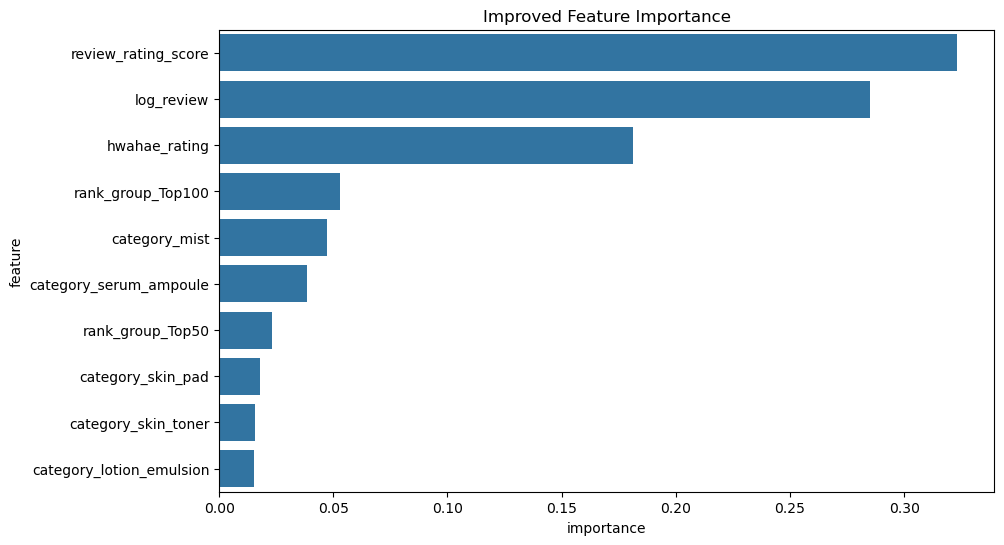

In [142]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df2.head(10),
    x="importance",
    y="feature"
)

plt.title("Improved Feature Importance")

plt.show()

In [143]:
importance_df2.head(10)

,feature,importance
2,review_rating_score,0.323237
1,log_review,0.284965
0,hwahae_rating,0.181306
9,rank_group_Top100,0.052947
4,category_mist,0.047027
5,category_serum_ampoule,0.038646
8,rank_group_Top50,0.023125
6,category_skin_pad,0.017899
7,category_skin_toner,0.015643
3,category_lotion_emulsion,0.015205


## 가설 3: 화해 인기 제품은 소비자 반응 특성에 따라 서로 다른 제품군으로 구분될 것이다.

화해 인기 제품이 서로 다른 특성을 가진 제품군으로 구분되는지 확인하기 위해 K-Means 군집 분석을 수행한다.

In [102]:
cluster_df = df[
    [
        "hwahae_rank",
        "hwahae_rating",
        "hwahae_review"
    ]
].copy()

In [103]:
# 로그 변환

cluster_df["log_review"] = np.log1p(
    cluster_df["hwahae_review"]
)

cluster_df.head()

,hwahae_rank,hwahae_rating,hwahae_review,log_review
0,1,4.74,27245,10.212662
1,2,4.70,34786,10.456999
2,3,4.69,17493,9.769613
3,4,4.43,94669,11.458152
4,5,4.70,9436,9.152393


In [104]:
X = cluster_df[
    [
        "hwahae_rank",
        "hwahae_rating",
        "log_review"
    ]
]

In [105]:
# 표준화

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [106]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    km.fit(X_scaled)

    inertia.append(km.inertia_)

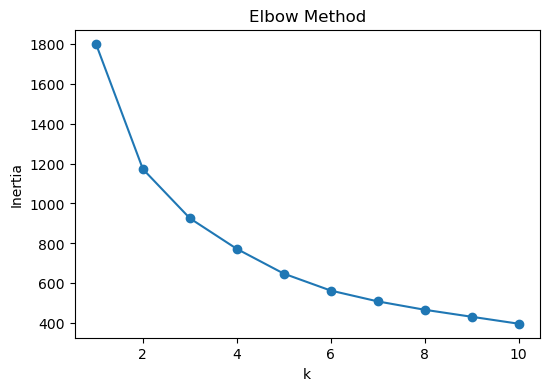

In [107]:
plt.figure(figsize=(6,4))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [108]:
from sklearn.metrics import silhouette_score

for k in range(2,8):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(k, score)

2 0.31506838808867543
3 0.2901869833259975
4 0.2832278208571188
5 0.2976345176868429
6 0.28569338991320437
7 0.2863584172839568


#### 군집 수 결정

Elbow Method 결과 K=3~4 구간에서 감소 폭이 완만해지는 경향을 보였다.
최종 군집 수를 K=3으로 설정하였다.

In [109]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

df["cluster"] = kmeans.fit_predict(
    X_scaled
)

In [110]:
df["cluster"].value_counts()

cluster
2    244
1    235
0    121
Name: count, dtype: int64

In [112]:
cluster_summary = (
    df.groupby("cluster")
      [
        [
            "hwahae_rank",
            "hwahae_rating",
            "hwahae_review",
            "olive_found"
        ]
      ]
      .mean()
      .round(2)
)

cluster_summary

,hwahae_rank,hwahae_rating,hwahae_review,olive_found
cluster,,,,
0,65.40,4.27,1061.03,0.45
1,22.96,4.56,5154.57,0.65
2,69.64,4.57,478.07,0.45


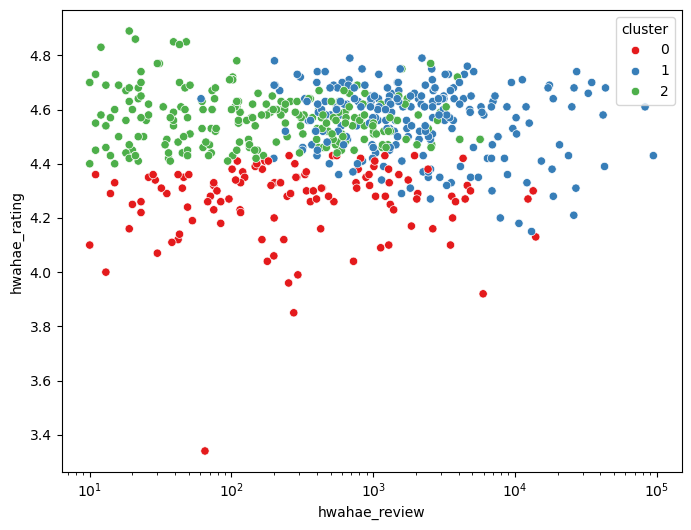

In [111]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="hwahae_review",
    y="hwahae_rating",
    hue="cluster",
    palette="Set1"
)

plt.xscale("log")

plt.show()